# SID530344829_Ass1a

## Learning outcomes
- Implement local macroblock motion estimation between consecutive video frames
- Maintain correct array, image coordination, channel and numeric-type conventions
- Validate a displacement estimator using known synthetic motion and traced real-video examples
- Justify block size, search radius, and vector-filtering choices using measured evidence
- Produce and independently validate a reproducible visualised video artefact


In [1]:
from pathlib import Path
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Video, display

candidates = [
    Path.cwd(),
]
WEEK_DIR = next((path for path in candidates if (path / "video_helpers.py").is_file()), None)
if WEEK_DIR is None:
    raise FileNotFoundError("Run this notebook from its folder or the repository root")
sys.path.insert(0, str(WEEK_DIR.resolve()))

from video_helpers import (
    ORIGINAL_VIDEO,
    inspect_video,
    plot_samples,
    validate_video,
    get_macroblocks,
    plot_macroblocks
)

In [2]:
vid_info = inspect_video(ORIGINAL_VIDEO)
validated = validate_video(ORIGINAL_VIDEO, expected_frames=None, expected_fps=None, expected_size=None)
validated, vid_info

(VideoInfo(path=PosixPath('/Users/medeline/Desktop/COMP3419-Python-Labs/SID530344829_Ass1a/data/monkey.avi'), width=720, height=576, channels=3, fps=25.0, frame_count=752, codec='cvid'),
 VideoInfo(path=PosixPath('/Users/medeline/Desktop/COMP3419-Python-Labs/SID530344829_Ass1a/data/monkey.avi'), width=720, height=576, channels=3, fps=25.0, frame_count=752, codec='cvid'))

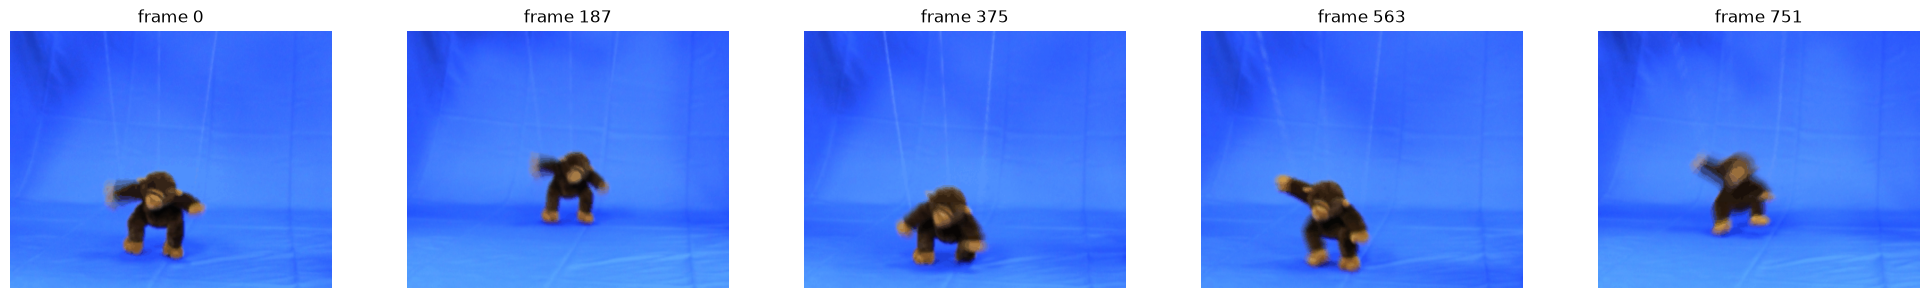

In [3]:
plot_samples(ORIGINAL_VIDEO, count = 5)

[(1, 1), (3, 1), (5, 1), (7, 1), (9, 1), (11, 1), (13, 1), (15, 1), (17, 1), (19, 1), (1, 3), (3, 3), (5, 3), (7, 3), (9, 3), (11, 3), (13, 3), (15, 3), (17, 3), (19, 3), (1, 5), (3, 5), (5, 5), (7, 5), (9, 5), (11, 5), (13, 5), (15, 5), (17, 5), (19, 5), (1, 7), (3, 7), (5, 7), (7, 7), (9, 7), (11, 7), (13, 7), (15, 7), (17, 7), (19, 7), (1, 9), (3, 9), (5, 9), (7, 9), (9, 9), (11, 9), (13, 9), (15, 9), (17, 9), (19, 9), (1, 11), (3, 11), (5, 11), (7, 11), (9, 11), (11, 11), (13, 11), (15, 11), (17, 11), (19, 11), (1, 13), (3, 13), (5, 13), (7, 13), (9, 13), (11, 13), (13, 13), (15, 13), (17, 13), (19, 13), (1, 15), (3, 15), (5, 15), (7, 15), (9, 15), (11, 15), (13, 15), (15, 15), (17, 15), (19, 15), (1, 17), (3, 17), (5, 17), (7, 17), (9, 17), (11, 17), (13, 17), (15, 17), (17, 17), (19, 17), (1, 19), (3, 19), (5, 19), (7, 19), (9, 19), (11, 19), (13, 19), (15, 19), (17, 19), (19, 19), (1, 21), (3, 21), (5, 21), (7, 21), (9, 21), (11, 21), (13, 21), (15, 21), (17, 21), (19, 21), (1, 

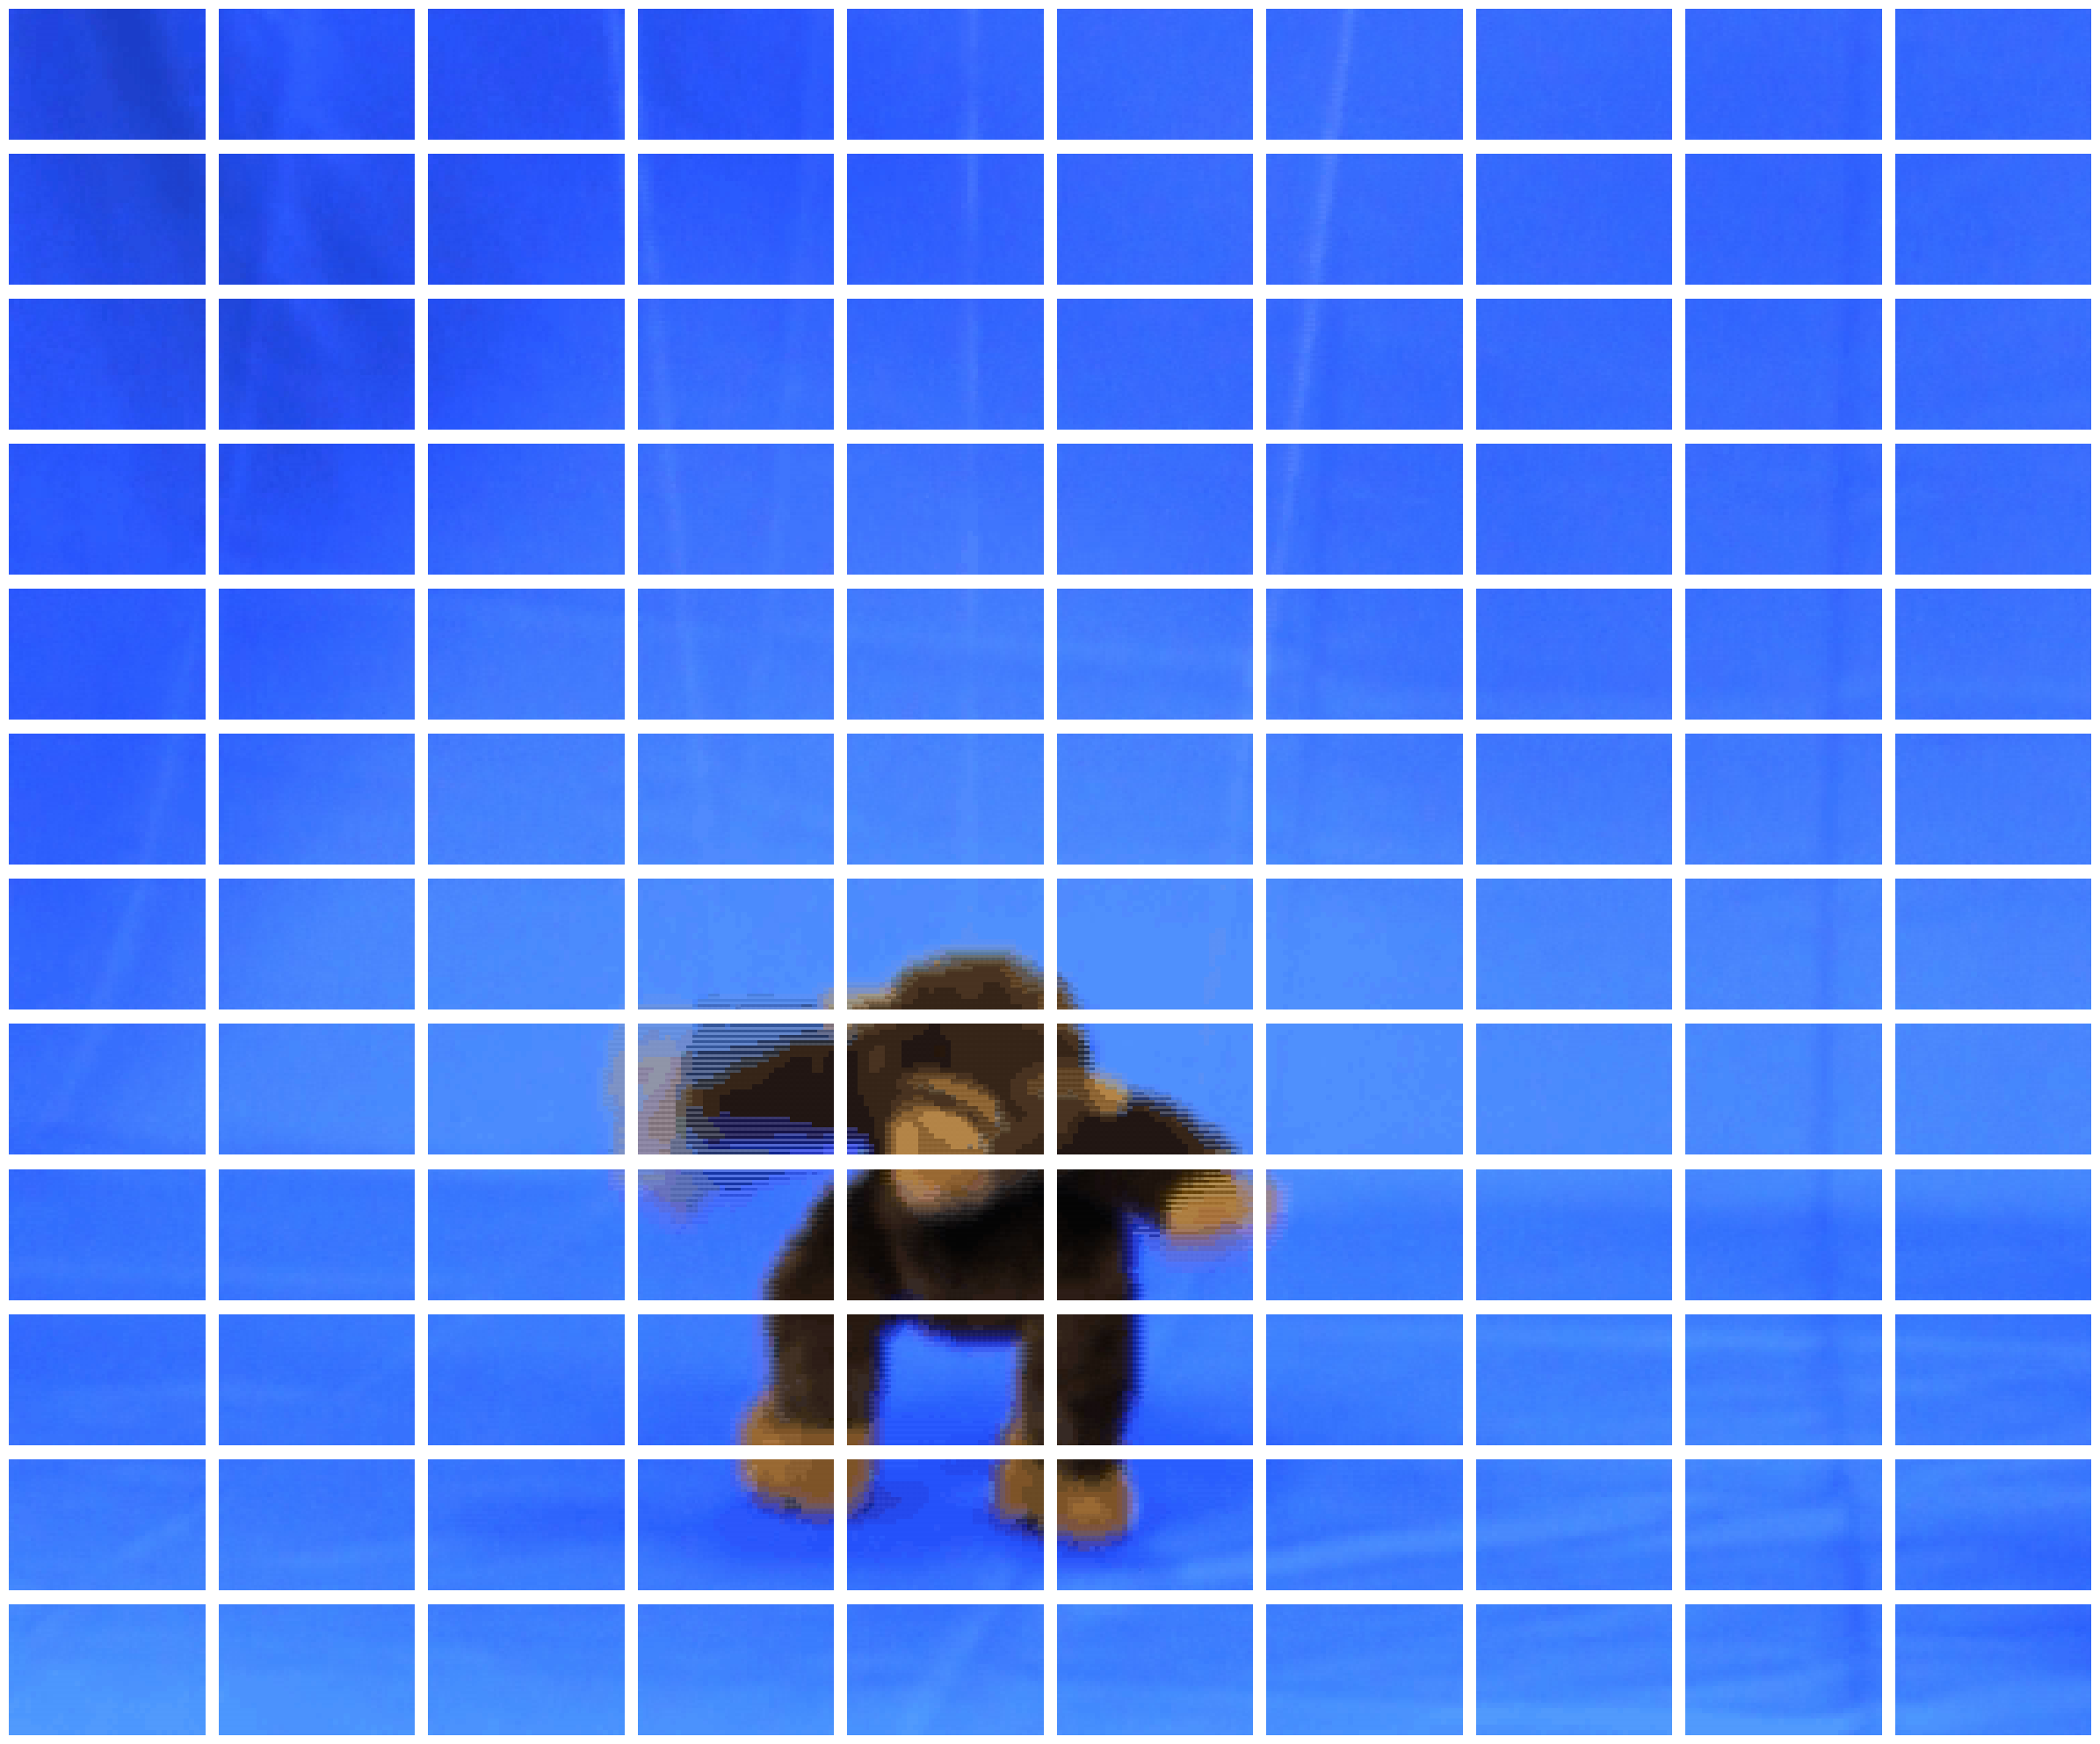

In [2]:
""" 
Steps:
- get macroblocks for some frame i
- 
"""

macroblocks = get_macroblocks(ORIGINAL_VIDEO)
plot_macroblocks(macroblocks)